# K-Nearest Neighbour (KNN) Classifier

## Introduction
The K-Nearest Neighbour (KNN) algorithm is a simple and intuitive supervised learning method used for classification. Given a positive integer ( k ) and a test observation ( x_0 ), the algorithm identifies the ( k ) closest data points in the training dataset using a distance metric such as Euclidean distance. It then assigns a class label to ( x_0 ) based on a majority vote among these nearest neighbors, meaning the class that appears most frequently is chosen as the prediction. KNN does not involve an explicit training phase; instead, it stores the entire training dataset and performs computations during prediction, which is why it is referred to as a lazy learning algorithm. The method effectively creates decision boundaries in the feature space, dividing it into regions corresponding to different classes. The choice of ( k ) plays a crucial role in determining the model’s behavior: a small ( k ) results in a highly flexible decision boundary that can capture fine patterns but may lead to overfitting, while a larger ( k ) produces smoother, more stable boundaries that are less sensitive to noise but may underfit the data.

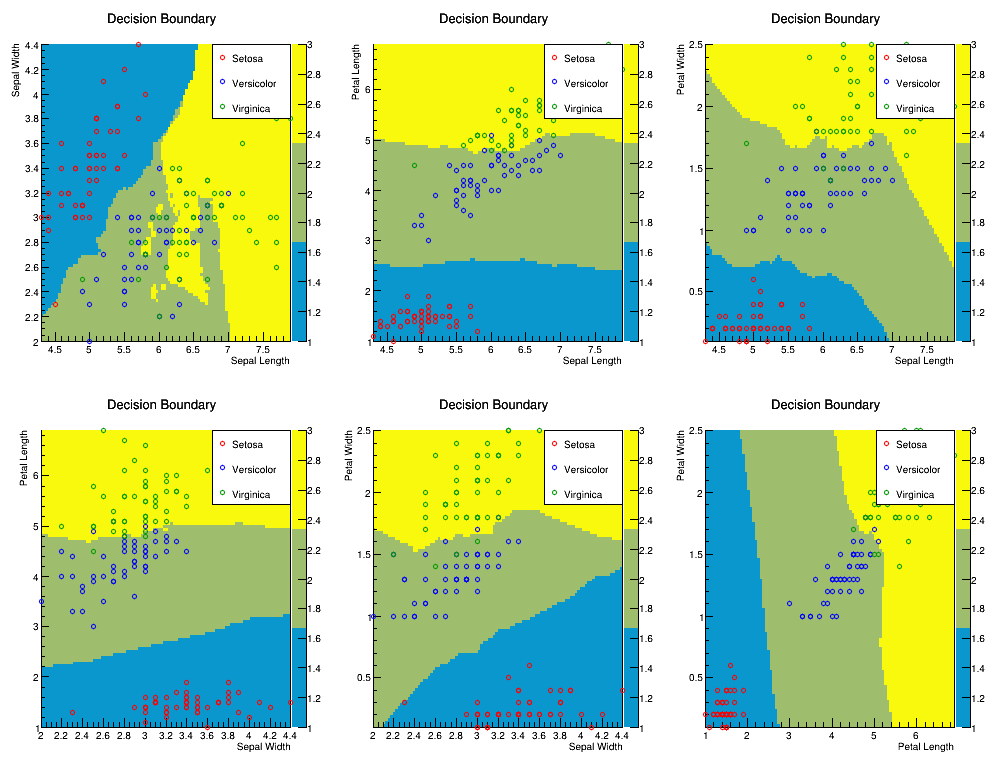

Here we apply KNN to the Iris dataset, which consists of measurements such as sepal length, sepal width, petal length, and petal width of flower to classify flowers into different species.


## Implementation from SCRATCH

In [1]:
import numpy as np


In [2]:

def euclidean_distance(x1,x2):

    distance = np.sqrt(np.sum((x1-x2)**2))

    return distance


In [3]:

class KNN:
    def __init__(self, k=3):
        self.k = k
        
    def fit(self, X, Y):
        self.X_train = X
        self.Y_train = Y

    def predict(self, X):
        predictions = []
        for x in X:
            pred = self._predict(x)
            predictions.append(pred)

        print(np.array(predictions))
        return np.array(predictions)

    def _predict(self,x):
        #compute the distances
        distances = []
        for x_train in self.X_train:
            distance = euclidean_distance(x, x_train)
            distances.append(distance)
            
        # get the closest k
        k_indices = np.argsort(distances)
        k_labels =[]

        for i in range(self.k):
            idx = k_indices[i]
            k_labels.append(self.Y_train[idx])

        # majority vote
        most_common_label = self._most_common_label(k_labels)
        return most_common_label

    def _most_common_label(self, y):

        counts = {} # dictionary to store key (label) and values also

    # count frequencies
        for label in y:
            if label in counts:
                counts[label] += 1
            else:
                counts[label] = 1

        max_count = -1
        most_common = None

    # find label with max count
        for label, count in counts.items():
            if count > max_count:
                max_count = count
                most_common = label

        return most_common


## Prediction using test data


[1 2 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]
Accuracy: 0.9666666666666667


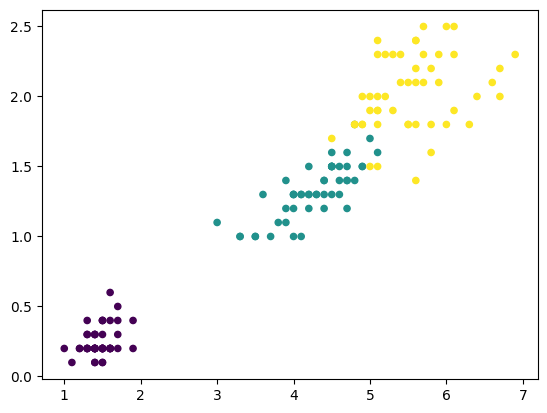

In [4]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
iris = datasets.load_iris()
X, y = iris.data, iris.target

# split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

# KNN model
clf = KNN(k=5)
clf.fit(X_train, Y_train)

# predict
predictions = clf.predict(X_test)

# accuracy
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

print("Accuracy:", accuracy(Y_test, predictions))

plt.scatter(X[:, 2], X[:, 3], c=y, s=20)
plt.show()


Pretty Good Accuracy !!






















## Using CERN ROOT and cpp:

#include <iostream>
#include <fstream>
#include <string>

#include "TCanvas.h"
#include "TGraph.h"
#include "TMultiGraph.h"
#include "TLegend.h"
#include "TH2F.h"


using namespace std;

const int ntype = 3;
const int nfeature = 4;
const int nsample = 50;
const int n_neighbors = 5;

string type_name[3] = {
    "Iris-setosa",
    "Iris-versicolor",
    "Iris-virginica"
};

const char* fname[4] = {
    "Sepal Length",
    "Sepal Width",
    "Petal Length",
    "Petal Width"
};

double _data[ntype][nfeature][nsample] = {0};
int count_type[ntype] = {0};

int KNN(double data_x, double data_y, int f1, int f2)
{
    vector<pair<double,int>> distVec;

    for(int itype = 0; itype < ntype; itype++)
    {
        for(int ij = 0; ij < nsample; ij++)
        {
            double dx = data_x - _data[itype][f1][ij];
            double dy = data_y - _data[itype][f2][ij];

            double d = sqrt(dx*dx + dy*dy);

            distVec.push_back({d, itype});
        }
    }

    sort(distVec.begin(), distVec.end());

    int vote[ntype] = {0};

    int kmax = min(n_neighbors, (int)distVec.size());

    for(int k = 0; k < kmax; k++)
        vote[ distVec[k].second ]++;

    int best = 0;

    for(int t = 1; t < ntype; t++)
        if(vote[t] > vote[best])
            best = t;

    return best;
}

TH2F* DrawDecisionBoundary(int f1, int f2)
{
    double xmin=1e9, xmax=-1e9;
    double ymin=1e9, ymax=-1e9;

    for(int t=0; t<ntype; t++)
    {
        for(int i=0; i<nsample; i++)
        {
            double x = _data[t][f1][i];
            double y = _data[t][f2][i];

            if(x < xmin) xmin = x;
            if(x > xmax) xmax = x;
            if(y < ymin) ymin = y;
            if(y > ymax) ymax = y;
        }
    }

    TH2F* hist_db = new TH2F("db",Form("Decision Boundary; %s; %s", fname[f1], fname[f2]),100, xmin, xmax,100, ymin, ymax);
    
    hist_db->SetStats(0);

    for(int ybin = 1; ybin <= hist_db->GetNbinsY(); ybin++)
    {
        for(int xbin = 1; xbin <= hist_db->GetNbinsX(); xbin++)
        {
            double x = hist_db->GetXaxis()->GetBinCenter(xbin);
            double y = hist_db->GetYaxis()->GetBinCenter(ybin);

            int cls = KNN(x, y, f1, f2);

            hist_db->SetBinContent(xbin, ybin, cls + 1);
        }
    }
    
    hist_db->SetContour(3);
    hist_db->Draw("colz:same");
    
}

int main()
{

  
    //    double data[ntype][nfeature][nsample] = {0};
    int count[ntype] = {0};

    
    ifstream file("iris_data.log");

    if (!file.is_open())
    {
        cout << "Cannot open iris_data.log\n";
        return 1;
    }

    double x1, x2, x3, x4;
    string name;

    while (file >> x1 >> x2 >> x3 >> x4 >> name)
    {
        for (int t = 0; t < ntype; t++)
        {
            if (name == type_name[t])
            {
                int id = count[t];

                if (id < nsample)
                {
                    _data[t][0][id] = x1;
                    _data[t][1][id] = x2;
                    _data[t][2][id] = x3;
                    _data[t][3][id] = x4;
                    count[t]++;
                }
            }
        }
    }

    cout << "Loaded: "
         << count[0] << " "
         << count[1] << " "
         << count[2] << endl;


    TCanvas* c1 = new TCanvas("c1","Iris Classification",1000,800);
    c1->Divide(3,2);

    int pad = 1;

    for (int f1 = 0; f1 < nfeature; f1++)
    {
        for (int f2 = f1 + 1; f2 < nfeature; f2++)
        {
            c1->cd(pad++);

            TGraph* g0 = new TGraph(nsample, _data[0][f1], _data[0][f2]);
            TGraph* g1 = new TGraph(nsample, _data[1][f1], _data[1][f2]);
            TGraph* g2 = new TGraph(nsample, _data[2][f1], _data[2][f2]);
	    
            g0->SetMarkerColor(kRed);
            g1->SetMarkerColor(kBlue);
            g2->SetMarkerColor(kGreen+2);

            g0->SetMarkerStyle(kOpenCircle);
            g1->SetMarkerStyle(kOpenCircle);
            g2->SetMarkerStyle(kOpenCircle);

            g0->SetMarkerSize(0.5);
            g1->SetMarkerSize(0.5);
            g2->SetMarkerSize(0.5);

	    TMultiGraph* mg = new TMultiGraph();

	    mg->Add(g0);
	    mg->Add(g1);
	    mg->Add(g2);

	    mg->SetTitle(Form("%s vs %s; %s; %s",
			      fname[f1], fname[f2],
			      fname[f1], fname[f2]));

	    DrawDecisionBoundary(f1, f2);

	    //mg->Draw("P:SAMES");
	    g0->Draw("P SAME");
            g1->Draw("P SAME");
            g2->Draw("P SAME");

	    TLegend* leg = new TLegend(0.65,0.7,0.9,0.9);
	    leg->AddEntry(g0,"Setosa","p");
	    leg->AddEntry(g1,"Versicolor","p");
	    leg->AddEntry(g2,"Virginica","p");
	    leg->Draw();
 
	}
	
	
    }


    //c1->Update();
    c1->SaveAs("pdf_test_knn_cpp.pdf");

    return 0;
}
